In [2]:
import osgeo
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_origin
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import binary_dilation, binary_fill_holes
from scipy.ndimage import distance_transform_edt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
# Function to convert row, column to lat, lon
def pixel_to_geo(row, col, transform):
    lon, lat = transform * (col, row)  # Using the affine transformation
    return lat, lon

In [4]:
# Open the GeoTIFF file
with rasterio.open(r"C:\Users\vwgei\Documents\PVOCAL\koppen_geiger_tif\1991_2020\koppen_geiger_0p5.tif") as dataset:
    land_transform = dataset.transform  # Affine transformation
    land_crs = dataset.crs  # Coordinate Reference System
    land_bounds = dataset.bounds  # Geographic bounds
    
    land_koppen = dataset.read(1)

print(land_transform)
print(land_crs)
print(land_bounds)
print(land_koppen)
print(land_koppen.shape)

land_valid_values = land_koppen.flatten()
land_unique, land_counts = np.unique(land_valid_values, return_counts=True)
print(np.asarray((land_unique, land_counts)).T)

# Create a lat/lon array the same size as the raster
kland_lat_lon = np.empty((land_koppen.shape[0], land_koppen.shape[1], 2), dtype=np.float32)

# Loop through all rows and columns to populate the lat_lon_array with lat/lon coordinates
for row in range(land_koppen.shape[0]):
    for col in range(land_koppen.shape[1]):
        lat, lon = pixel_to_geo(row, col, land_transform)
        kland_lat_lon[row, col] = [lat, lon]

kland_lat_lon = kland_lat_lon.squeeze()
print(kland_lat_lon.shape)

| 0.50, 0.00,-180.00|
| 0.00,-0.50, 90.00|
| 0.00, 0.00, 1.00|
EPSG:4326
BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]]
(360, 720)
[[     0 163753]
 [     1   3581]
 [     2   2079]
 [     3   6678]
 [     4   8423]
 [     5   3065]
 [     6   3098]
 [     7   3712]
 [     8    839]
 [     9    460]
 [    11   1479]
 [    12    522]
 [    14   2632]
 [    15   1856]
 [    16    104]
 [    17     80]
 [    18    270]
 [    19   1125]
 [    20      6]
 [    21    508]
 [    22    774]
 [    23   1496]
 [    24    188]
 [    25    798]
 [    26   5134]
 [    27  11122]
 [    28     92]
 [    29   7733]
 [    30  27593]]
(360, 720, 2)


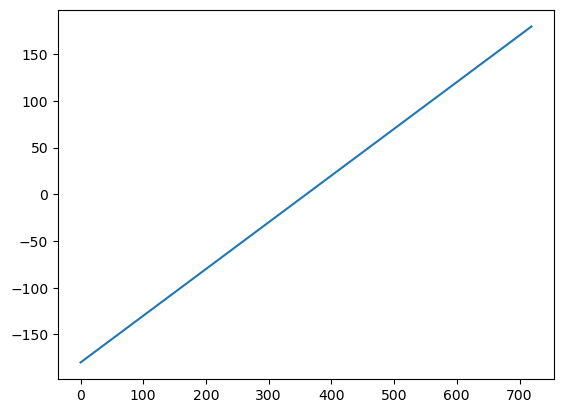

In [5]:
plt.plot(kland_lat_lon[0,:,1])

In [6]:
# Define the mapping dictionary
remap_dict = {
    4: 6,
    5: 7,
    8: 11,
    9: 12,
    10: 13,
    11: 8,
    12: 9
}


# Open the GeoTIFF file
with rasterio.open(r"C:\Users\vwgei\Documents\PVOCAL\ArcMap\koppen_walterscheid_ocean.tif") as dataset:
    ocean_transform = dataset.transform  # Affine transformation
    ocean_crs = dataset.crs  # Coordinate Reference System
    ocean_bounds = dataset.bounds  # Geographic bounds
    
    ocean_koppen = dataset.read(1)

# Create an array to hold the remapped values, starting with the original values
remapped_koppen = np.copy(ocean_koppen)

# Prepare a lookup table (fast remapping)
lookup_table = np.arange(31)  # Create an array from 0 to 30
for old_value, new_value in remap_dict.items():
    lookup_table[old_value] = new_value

# Apply the remap all at once
remapped_koppen = np.take(lookup_table, ocean_koppen)

print(ocean_transform)
print(ocean_crs)
print(ocean_bounds)
print(ocean_koppen)
print(ocean_koppen.shape)

ocean_valid_values = ocean_koppen.flatten()
ocean_unique, ocean_counts = np.unique(ocean_valid_values, return_counts=True)
print(np.asarray((ocean_unique, ocean_counts)).T)

# Optional: Check unique values to confirm
unique_remapped, counts_remapped = np.unique(remapped_koppen, return_counts=True)
print(np.asarray((unique_remapped, counts_remapped)).T)

# Save the remapped raster if needed
with rasterio.open(
    r"C:\Users\vwgei\Documents\PVOCAL\ArcMap\koppen_walterscheid_ocean_remapped.tif",
    'w',
    driver='GTiff',
    height=ocean_koppen.shape[0],
    width=ocean_koppen.shape[1],
    count=1,
    dtype=ocean_koppen.dtype,
    crs=ocean_crs,
    transform=ocean_transform
) as dst:
    dst.write(remapped_koppen, 1)

print("✅ Remapping complete! Raster saved with new values.")

# # Create a lat/lon array the same size as the raster
# kocean_lat_lon = np.empty((ocean_koppen.shape[0], ocean_koppen.shape[1], 2), dtype=np.float32)

# # Loop through all rows and columns to populate the lat_lon_array with lat/lon coordinates
# for row in range(ocean_koppen.shape[0]):
#     for col in range(ocean_koppen.shape[1]):
#         lat, lon = pixel_to_geo(row, col, ocean_transform)
#         kocean_lat_lon[row, col] = [lat, lon]

# kocean_lat_lon = kocean_lat_lon.squeeze()
# print(kocean_lat_lon.shape)

| 0.50, 0.00, 0.00|
| 0.00,-0.50, 88.25|
| 0.00, 0.00, 1.00|
EPSG:4326
BoundingBox(left=0.0, bottom=-76.25, right=360.0, top=88.25)
[[30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]
 ...
 [30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]
 [30 30 30 ... 30 30 30]]
(329, 720)
[[    1 17497]
 [    2  6876]
 [    3 60653]
 [    4  1247]
 [    6    47]
 [    8  3276]
 [    9   988]
 [   10     9]
 [   11  2793]
 [   12  1573]
 [   14 15256]
 [   15 34434]
 [   16  8701]
 [   29 54134]
 [   30 29396]]
[[    1 17497]
 [    2  6876]
 [    3 60653]
 [    6  1294]
 [    8  2793]
 [    9  1573]
 [   11  3276]
 [   12   988]
 [   13     9]
 [   14 15256]
 [   15 34434]
 [   16  8701]
 [   29 54134]
 [   30 29396]]
✅ Remapping complete! Raster saved with new values.


In [7]:
# kocean_lat_lon = np.zeros_like(kland_lat_lon)

# longitudes = kland_lat_lon[:,:,1]
# longitudes += 180

# longitudes[longitudes > 180] -= 360

# kocean_lat_lon[:,:,1] = longitudes

# # Use np.roll to shift columns by 'midpoint' positions along axis 1 (columns)
# kocean_lat_lon[:,:,1] = np.roll(kocean_lat_lon[:,:,1], shift=359, axis=1)

# plt.plot(kocean_lat_lon[0,:,1])

In [8]:
row = np.arange(0,720,1, dtype=int)
EFrow = np.full_like(row, 30)

In [9]:
steven_walterscheild_indices = np.arange(3,332,1)
# full_indicies = np.arange(0,360,1)

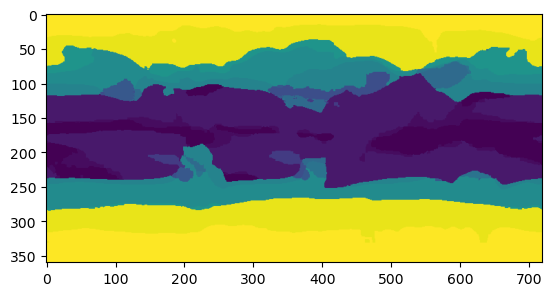

In [10]:
full_ocean_koppen = np.zeros((360,720))
mi = 0
for ri in range(0,360,1):
    if ri in steven_walterscheild_indices:
        full_ocean_koppen[ri] = remapped_koppen[mi]
        mi = mi + 1
    else:
        full_ocean_koppen[ri] = EFrow

full_ocean_koppen = np.roll(full_ocean_koppen, shift=359, axis=1)

plt.imshow(full_ocean_koppen)

In [11]:
type(full_ocean_koppen)

numpy.ndarray

In [12]:
full_ocean_ll = kland_lat_lon
# full_ocean_ll[:,:,0] = kland_lat_lon[:,:,0]
# full_ocean_ll[:,:,1] = longitudes

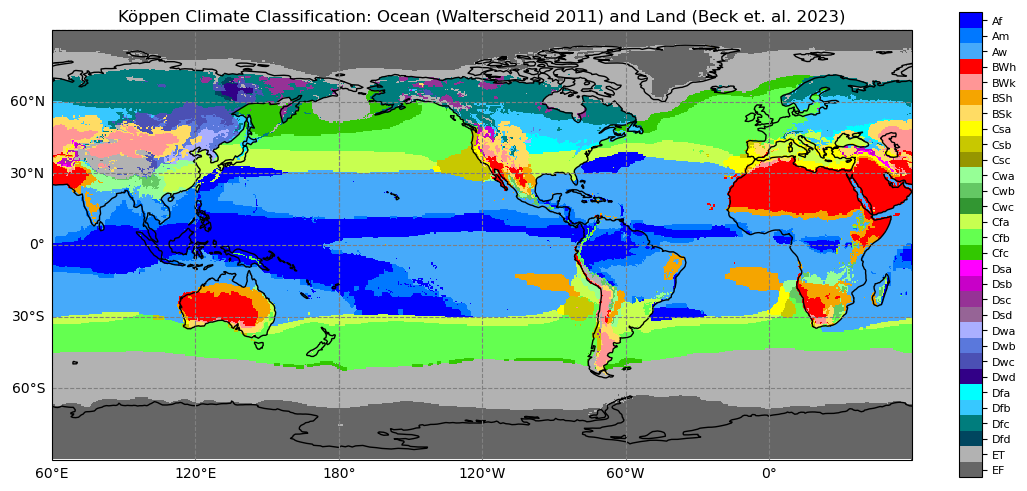

In [13]:
# Define classification values
land_classes = np.arange(1, 31)  # 1 to 30 for land
ocean_classes = np.array([1, 2, 3, 4, 6, 8, 9, 10, 11, 12, 14, 15, 16, 29, 30])

koppen_labels = [
    "Af", "Am", "Aw", "BWh", "BWk", "BSh", "BSk", "Csa", "Csb", "Csc",
    "Cwa", "Cwb", "Cwc", "Cfa", "Cfb", "Cfc", "Dsa", "Dsb", "Dsc", "Dsd",
    "Dwa", "Dwb", "Dwc", "Dwd", "Dfa", "Dfb", "Dfc", "Dfd", "ET", "EF"
]

# Normalized land colors (0-1 range)
land_colors = {
    1: np.array([0, 0, 255]) / 255,  
    2: np.array([0, 120, 255]) / 255,  
    3: np.array([70, 170, 250]) / 255,  
    4: np.array([255, 0, 0]) / 255,  
    5: np.array([255, 150, 150]) / 255,  
    6: np.array([245, 165, 0]) / 255,  
    7: np.array([255, 220, 100]) / 255,  
    8: np.array([255, 255, 0]) / 255,  
    9: np.array([200, 200, 0]) / 255,  
    10: np.array([150, 150, 0]) / 255,  
    11: np.array([150, 255, 150]) / 255,  
    12: np.array([100, 200, 100]) / 255,  
    13: np.array([50, 150, 50]) / 255,  
    14: np.array([200, 255, 80]) / 255,  
    15: np.array([100, 255, 80]) / 255,  
    16: np.array([50, 200, 0]) / 255,  
    17: np.array([255, 0, 255]) / 255,  
    18: np.array([200, 0, 200]) / 255,  
    19: np.array([150, 50, 150]) / 255,  
    20: np.array([150, 100, 150]) / 255,  
    21: np.array([170, 175, 255]) / 255,  
    22: np.array([90, 120, 220]) / 255,  
    23: np.array([75, 80, 180]) / 255,  
    24: np.array([50, 0, 135]) / 255,  
    25: np.array([0, 255, 255]) / 255,  
    26: np.array([55, 200, 255]) / 255,  
    27: np.array([0, 125, 125]) / 255,  
    28: np.array([0, 70, 95]) / 255,  
    29: np.array([178, 178, 178]) / 255,  
    30: np.array([102, 102, 102]) / 255  
}

# Normalized ocean colors (0-1 range)
ocean_colors = {
    1: np.array([76, 114, 0]) / 255,  
    2: np.array([152, 129, 0]) / 255,  
    3: np.array([205, 245, 122]) / 255,  
    4: np.array([155, 76, 0]) / 255,  
    6: np.array([255, 211, 128]) / 255,  
    8: np.array([0, 115, 76]) / 255,  
    9: np.array([0, 168, 132]) / 255,  
    10: np.array([0, 220, 197]) / 255,  
    11: np.array([68, 78, 139]) / 255,  
    12: np.array([123, 142, 245]) / 255,  
    14: np.array([115, 0, 0]) / 255,  
    15: np.array([168, 0, 0]) / 255,  
    16: np.array([245, 123, 122]) / 255,  
    29: np.array([199, 0, 255]) / 255,  
    30: np.array([77, 0, 116]) / 255  
}

# Create colormaps
land_cmap = ListedColormap([land_colors[i] for i in sorted(land_colors.keys())])
ocean_cmap = ListedColormap([ocean_colors[i] for i in sorted(ocean_colors.keys())])

# Normalize classification values to match colormap indices
land_norm = BoundaryNorm(np.arange(1, 32), land_cmap.N)
ocean_norm = BoundaryNorm(ocean_classes, ocean_cmap.N)

# Reverse colormap and normalization
reversed_land_cmap = ListedColormap(land_cmap.colors[::-1])  # Reverse colors
reversed_norm = BoundaryNorm(np.arange(1, 32), reversed_land_cmap.N)

# Mask land values where they are 0
masked_land_koppen = np.ma.masked_where(land_koppen == 0, land_koppen)

# Create figure
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=240)})
# ax.set_extent([-136, 120, -90, 90], crs=ccrs.PlateCarree(central_longitude=240))


# Plot ocean data first
ocean_plot = ax.pcolormesh(full_ocean_ll[..., 1], full_ocean_ll[..., 0], full_ocean_koppen,
                            # cmap=ocean_cmap, norm=ocean_norm, shading='auto', transform=ccrs.PlateCarree())
                            cmap=land_cmap, norm=land_norm, shading='auto', transform=ccrs.PlateCarree())


# Plot land data on top
land_plot = ax.pcolormesh(kland_lat_lon[..., 1], kland_lat_lon[..., 0], masked_land_koppen,
                          cmap=land_cmap, norm=land_norm, shading='auto', transform=ccrs.PlateCarree())

# Add coastlines
ax.coastlines()

# Add gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
gl.top_labels = gl.right_labels = False  # optional: turn off top/right labels for cleaner look

# Add colorbars
# plt.colorbar(ocean_plot, ax=ax, orientation='horizontal', label="Ocean Koppen Classification", fraction=0.1)
# plt.colorbar(land_plot, ax=ax, orientation='vertical', label="Land Koppen Classification", fraction=0.025)

tick_positions = np.arange(1, 31) + 0.5  # Shift ticks to the middle of each color band

# Create colorbar with proper labels
cbar = plt.colorbar(land_plot, ax=ax, orientation='vertical', fraction=0.025)
cbar.set_ticks(tick_positions)  # Keep same tick positions
cbar.set_ticklabels(koppen_labels)  # Reverse the label order
cbar.ax.invert_yaxis()  # Flip the colorbar to align labels properly
cbar.ax.tick_params(labelsize=8)  # Adjust font size for readability
cbar.ax.minorticks_off()

# Title and show plot
plt.title("Köppen Climate Classification: Ocean (Walterscheid 2011) and Land (Beck et. al. 2023)")
plt.savefig(r"C:\Users\vwgei\Documents\PVOCAL\plots\standalone\koppen_class_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
np.save(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\ocean_koppen_data.npy",full_ocean_koppen)
np.save(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\ocean_koppen_ll.npy",full_ocean_ll)
np.save(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\land_koppen_data.npy",land_koppen)
np.save(r"C:\Users\vwgei\Documents\PVOCAL\data\Koppen\land_koppen_ll.npy", kland_lat_lon)

In [13]:
# full_ocean_koppen # shape (360,720).
# full_ocean_ll # shape (360,720,2). Dimension 0 is laitude, Dimension 1 is longitude

# land_koppen # shape (360,720).
# kland_lat_lon # shape (360,720,2). Dimension 0 is laitude, Dimension 1 is longitude

# # Plot ocean first and then land (ie. land on top of ocean) on a platecarre projection.
# # the "invalid" value for 'land_koppen' is 0 please mask it out so we can see the ocean data 

# # Create a Plate Carrée projection
# projection = ccrs.PlateCarree()

# # Mask invalid land values (0s)
# masked_land_koppen = np.ma.masked_where(land_koppen == 0, land_koppen)

# # Create figure and axis
# fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': projection})

# # Plot ocean data
# ocean_plot = ax.pcolormesh(full_ocean_ll[..., 1], full_ocean_ll[..., 0], full_ocean_koppen, 
#                             cmap='Blues', shading='auto', transform=projection)

# # Plot land data on top
# land_plot = ax.pcolormesh(kland_lat_lon[..., 1], kland_lat_lon[..., 0], masked_land_koppen, 
#                           cmap='terrain', shading='auto', transform=projection)

# # Add coastlines and colorbars
# ax.coastlines()
# # plt.colorbar(ocean_plot, ax=ax, orientation='horizontal', label="Ocean Koppen")
# # plt.colorbar(land_plot, ax=ax, orientation='horizontal', label="Land Koppen")

# # Show the plot
# plt.title("Köppen Climate Classification: Ocean and Land")
# plt.show()